# Experiment 04 — Clean vs Perturbed Disease Classification
**Purpose.**  Directly answer RYAI Reviewer 3 (#10) and Meta-Radiology
Reviewer 2 (#4): report disease AUC for each model on the *same test set*
with and without perturbation.  Produces the ΔAUC evidence that the
"embedding-level suppression" story currently lacks.
**Pipeline.**
  1. Build stratified disease train/test split per dataset.
  2. Extract CLS embeddings on CLEAN test images (per model).
  3. Extract CLS embeddings on PERTURBED test images for each perturbation.
     Perturbations: isotropic blur (patch 4, 8), directional blur
     (cranio-caudal + lateral, patch 32, 64), reticular, ground-glass.
  4. Train disease classifier on CLEAN train embeddings (standard).
  5. Evaluate on CLEAN test (baseline) and PERTURBED test (perturbed).
  6. Report per-model, per-disease, per-perturbation ΔAUC with paired
     bootstrap CI + DeLong.
**How to run.**
    export DATASET=nih        # or 'emory'
    export HF_TOKEN=...       # DINOv3 is gated
    jupyter nbconvert --execute --to notebook 04_CleanVsPerturbed_DiseaseClassification.ipynb
Writes a single parquet `exp04_<dataset>_results.parquet` that the combined
analysis notebook (09) ingests from both servers.

In [1]:
import os, sys, gc, json, time
from pathlib import Path

# --- Path to the repository 'common' package -----------------------------
# Adjust ONLY if you cloned the repo in a different location on this server
REPO_ROOT = Path(os.environ.get("REPO_ROOT", "/home/saptpurk/embeddings-noise-eliminators/v4"))
sys.path.insert(0, str(REPO_ROOT))

# --- Server / dataset selection ------------------------------------------
# Either set DATASET beforehand, OR uncomment the line below:
# os.environ["DATASET"] = "nih"      # or "emory"

from common import (
    get_config, PARAMS, MODELS, HF_TOKEN, models_to_run,
    LocalizedBlurInjector, DirectionalMotionBlurInjector,
    ReticularPatternInjector, GroundGlassInjector,
    EmbeddingExtractor, train_probe, save_probe,
    load_disease_labels, load_and_pad, stratified_split,
    paired_bootstrap_delta_auc, delong_test,
)

CFG = get_config()
OUT = CFG.output_dir("exp04_clean_vs_perturbed")
print(f"Dataset: {CFG.name}  |  Output: {OUT}")

Dataset: NIH-CXR14  |  Output: /home/saptpurk/embeddings-noise-eliminators/v4_work/v4_exp04_clean_vs_perturbed_nih


In [2]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

DISEASES     = ["cardiomegaly", "edema", "lung_lesion"]
MODEL_NAMES  = models_to_run()          # env MODELS_TO_RUN, default = all
print(f"Running models: {MODEL_NAMES}")
SEED         = PARAMS.random_seed

# Perturbation matrix  (name, injector, patch_size)
def _build_perturbations():
    return [
        # Isotropic blur  — v3 artefact, retained for continuity
        ("iso_blur_p4",   LocalizedBlurInjector(seed=SEED), 4),
        ("iso_blur_p8",   LocalizedBlurInjector(seed=SEED), 8),
        # Directional motion blur — NEW v4 physics-motivated
        ("dir_blur_cranio_p32",
         DirectionalMotionBlurInjector(seed=SEED, angle_deg=90.0,
                                       kernel_length=PARAMS.directional_kernel_length),
         32),
        ("dir_blur_cranio_p64",
         DirectionalMotionBlurInjector(seed=SEED, angle_deg=90.0,
                                       kernel_length=PARAMS.directional_kernel_length),
         64),
        ("dir_blur_lateral_p32",
         DirectionalMotionBlurInjector(seed=SEED, angle_deg=0.0,
                                       kernel_length=PARAMS.directional_kernel_length),
         32),
        ("dir_blur_lateral_p64",
         DirectionalMotionBlurInjector(seed=SEED, angle_deg=0.0,
                                       kernel_length=PARAMS.directional_kernel_length),
         64),
        # Pathology-mimicking patterns — NEW v4
        ("reticular_fine_p32",
         ReticularPatternInjector(seed=SEED, period_px=3,
                                  amplitude=PARAMS.reticular_amplitude), 32),
        ("reticular_coarse_p64",
         ReticularPatternInjector(seed=SEED, period_px=6,
                                  amplitude=PARAMS.reticular_amplitude), 64),
        ("ground_glass_p64",
         GroundGlassInjector(seed=SEED, sigma_px=PARAMS.ground_glass_sigma,
                             amplitude=PARAMS.ground_glass_amplitude), 64),
    ]

PERTURBATIONS = _build_perturbations()

Running models: ['dinov3', 'medsiglip']


## 1. Build (or load) disease-stratified splits

In [3]:
SPLIT_PATH = OUT / "disease_split.csv"

if SPLIT_PATH.exists():
    df_all = pd.read_csv(SPLIT_PATH)
    print(f"Loaded cached split: {len(df_all)} rows")
else:
    df_all = load_disease_labels(CFG, DISEASES)
    # Multilabel stratification: concat disease labels into a stratum key
    df_all["_stratum"] = df_all[DISEASES].astype(str).agg("".join, axis=1)
    train_df, test_df = stratified_split(df_all, "_stratum",
                                         test_frac=0.2, seed=SEED)
    train_df["split"], test_df["split"] = "train", "test"
    df_all = pd.concat([train_df, test_df], ignore_index=True)
    df_all.drop(columns=["_stratum"], inplace=True)
    df_all.to_csv(SPLIT_PATH, index=False)
    print(f"Created split: train={len(train_df)}  test={len(test_df)}")

train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
test_df  = df_all[df_all["split"] == "test"].reset_index(drop=True)

for d in DISEASES:
    print(f"  {d:>15s}: train_pos={int(train_df[d].sum()):>6d} / {len(train_df)}  "
          f"test_pos={int(test_df[d].sum()):>6d} / {len(test_df)}")

Loaded cached split: 112120 rows
     cardiomegaly: train_pos=  2220 / 89694  test_pos=   556 / 22426
            edema: train_pos=  1841 / 89694  test_pos=   462 / 22426
      lung_lesion: train_pos=  5064 / 89694  test_pos=  1267 / 22426


## 2. Extract CLS embeddings on CLEAN train + CLEAN test + each perturbed test

In [4]:
def _batches(items, bs):
    for i in range(0, len(items), bs):
        yield items[i:i + bs]

def extract_clean_for_df(extractor, df, tag):
    """Return (N, D) CLS embeddings for the `image_path` column of df."""
    emb_path = OUT / f"emb_clean_{extractor.model_name}_{tag}.npy"
    if emb_path.exists():
        print(f"  cached {emb_path.name}")
        return np.load(emb_path)
    from common import parallel_iter
    out = []
    paths = df["image_path"].tolist()
    n_batches = (len(paths) + PARAMS.batch_size - 1) // PARAMS.batch_size
    for clean_imgs, _, _ in tqdm(
            parallel_iter(paths, CFG.target_size,
                          batch_size=PARAMS.batch_size,
                          num_workers=PARAMS.num_workers),
            total=n_batches,
            desc=f"CLEAN {tag} / {extractor.model_name}"):
        out.append(extractor.extract_cls(clean_imgs))
    X = np.vstack(out)
    np.save(emb_path, X)
    return X


def extract_perturbed_for_df(extractor, df, injector, patch_size, pert_name):
    emb_path = OUT / f"emb_pert_{extractor.model_name}_{pert_name}_test.npy"
    loc_path = OUT / f"loc_pert_{pert_name}_test.json"
    if emb_path.exists():
        print(f"  cached {emb_path.name}")
        return np.load(emb_path)
    from common import parallel_iter
    out = []
    paths = df["image_path"].tolist()
    n_batches = (len(paths) + PARAMS.batch_size - 1) // PARAMS.batch_size
    for _, pert_imgs, _ in tqdm(
            parallel_iter(paths, CFG.target_size,
                          batch_size=PARAMS.batch_size,
                          num_workers=PARAMS.num_workers,
                          injector=injector, patch_size=patch_size),
            total=n_batches,
            desc=f"PERT {pert_name} / {extractor.model_name}"):
        out.append(extractor.extract_cls(pert_imgs))
    X = np.vstack(out)
    np.save(emb_path, X)
    return X

In [5]:
train_embs, test_embs_clean = {}, {}
test_embs_pert = {m: {} for m in MODEL_NAMES}

for model_name in MODEL_NAMES:
    print(f"\n=== {model_name.upper()} ===")
    ext = EmbeddingExtractor(model_name,
                             hf_token=HF_TOKEN if MODELS[model_name]["requires_token"] else None)
    train_embs[model_name]      = extract_clean_for_df(ext, train_df, "train")
    test_embs_clean[model_name] = extract_clean_for_df(ext, test_df,  "test")
    for pert_name, injector, patch_size in PERTURBATIONS:
        test_embs_pert[model_name][pert_name] = \
            extract_perturbed_for_df(ext, test_df, injector, patch_size, pert_name)
    ext.close()
    del ext; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


=== DINOV3 ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

  cached emb_clean_dinov3_train.npy


  cached emb_clean_dinov3_test.npy


...

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


PERT reticular_coarse_p64 / medsiglip:   0%|          | 0/1402 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


PERT ground_glass_p64 / medsiglip:   0%|          | 0/1402 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


## 3. Train disease classifier on CLEAN train, evaluate clean + perturbed test

In [6]:
records = []

for model_name in MODEL_NAMES:
    Xtr = train_embs[model_name]
    Xte_clean = test_embs_clean[model_name]
    for disease in DISEASES:
        ytr = train_df[disease].values
        yte = test_df[disease].values
        if ytr.sum() < 10 or yte.sum() < 10:
            print(f"skip {model_name}/{disease}: too few positives")
            continue

        probe, art = train_probe(
            Xtr, ytr, Xte_clean, yte,
            name=f"{model_name}_{disease}_CLEAN",
            C_grid=PARAMS.lr_C_grid, n_boot=PARAMS.n_bootstrap,
            max_iter=PARAMS.lr_max_iter, seed=SEED, verbose=False,
        )
        save_probe(probe, art, OUT, stem=f"disease_{model_name}_{disease}_clean")

        clf, scaler = art["classifier"], art["scaler"]
        proba_clean = probe.y_proba

        # Evaluate on each perturbation
        for pert_name, _, _ in PERTURBATIONS:
            Xte_p = scaler.transform(test_embs_pert[model_name][pert_name])
            proba_pert = clf.predict_proba(Xte_p)[:, 1]

            delta = paired_bootstrap_delta_auc(
                yte, proba_clean, proba_pert,
                n_boot=PARAMS.n_bootstrap, seed=SEED,
            )
            dlg = delong_test(yte, proba_clean, proba_pert)

            records.append(dict(
                dataset=CFG.dataset, model=model_name, disease=disease,
                perturbation=pert_name,
                auc_clean=delta["auc_clean"],
                auc_perturbed=delta["auc_perturbed"],
                delta_auc=delta["delta"],
                delta_ci_low=delta["delta_ci"][0],
                delta_ci_high=delta["delta_ci"][1],
                delong_z=dlg["z"], delong_p=dlg["p_value"],
                n_test=len(yte), n_pos_test=int(yte.sum()),
            ))
            print(f"{model_name:>8s} | {disease:>12s} | {pert_name:>22s}  "
                  f"ΔAUC={delta['delta']:+.4f}  "
                  f"[{delta['delta_ci'][0]:+.4f}, {delta['delta_ci'][1]:+.4f}]  "
                  f"DeLong p={dlg['p_value']:.4g}")

  dinov3 | cardiomegaly |            iso_blur_p4  ΔAUC=-0.0000  [-0.0003, +0.0002]  DeLong p=0.7772


  dinov3 | cardiomegaly |            iso_blur_p8  ΔAUC=-0.0001  [-0.0003, +0.0001]  DeLong p=0.3474


  dinov3 | cardiomegaly |    dir_blur_cranio_p32  ΔAUC=+0.0004  [-0.0002, +0.0010]  DeLong p=0.1842


  dinov3 | cardiomegaly |    dir_blur_cranio_p64  ΔAUC=+0.0016  [+0.0000, +0.0033]  DeLong p=0.05297


  dinov3 | cardiomegaly |   dir_blur_lateral_p32  ΔAUC=+0.0005  [-0.0000, +0.0011]  DeLong p=0.06755


...

medsiglip |  lung_lesion |   dir_blur_lateral_p32  ΔAUC=-0.0001  [-0.0007, +0.0005]  DeLong p=0.7957


medsiglip |  lung_lesion |   dir_blur_lateral_p64  ΔAUC=+0.0014  [-0.0007, +0.0033]  DeLong p=0.1614


medsiglip |  lung_lesion |     reticular_fine_p32  ΔAUC=-0.0002  [-0.0005, +0.0001]  DeLong p=0.1625


medsiglip |  lung_lesion |   reticular_coarse_p64  ΔAUC=+0.0111  [+0.0067, +0.0149]  DeLong p=1.706e-06


medsiglip |  lung_lesion |       ground_glass_p64  ΔAUC=+0.0023  [+0.0008, +0.0039]  DeLong p=0.003877


In [7]:
results_df = pd.DataFrame(records)
_run_tag = os.environ.get("RUN_TAG", "")
_suffix = ("_" + _run_tag) if _run_tag else ""
out_path = OUT / f"exp04_{CFG.dataset}_results{_suffix}.parquet"
results_df.to_parquet(out_path, index=False)
print(f"\nSaved {len(results_df)} rows -> {out_path}")


Saved 54 rows -> /home/saptpurk/embeddings-noise-eliminators/v4_work/v4_exp04_clean_vs_perturbed_nih/exp04_nih_results_gpu1.parquet


## 4. Sanity plot
Visual ΔAUC heatmap.  Not required for the paper, but useful for debugging.

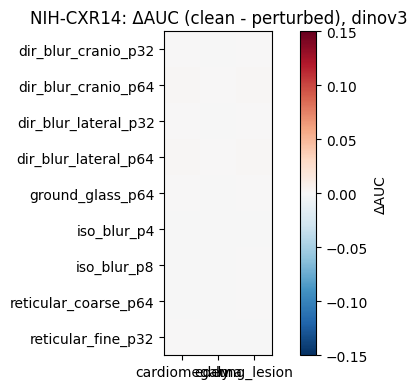

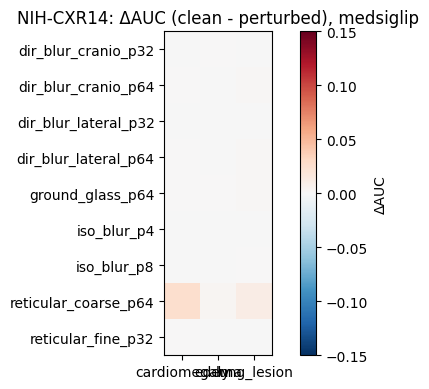

In [8]:
try:
    import matplotlib.pyplot as plt
    for model_name in MODEL_NAMES:
        sub = results_df[results_df["model"] == model_name]
        if sub.empty: continue
        pivot = sub.pivot(index="perturbation", columns="disease",
                          values="delta_auc")
        fig, ax = plt.subplots(figsize=(6, 4))
        im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-0.15, vmax=0.15)
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
        ax.set_title(f"{CFG.name}: ΔAUC (clean - perturbed), {model_name}")
        plt.colorbar(im, ax=ax, label="ΔAUC")
        plt.tight_layout()
        plt.savefig(OUT / f"heatmap_{model_name}.png", dpi=200)
        plt.show()
except Exception as e:
    print(f"Plot skipped: {e}")